<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/ccf_multi_galaxies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CCF — Mesure de vitesse radiale par corrélation croisée
**Méthode** : corrélation croisée en espace log(λ) — identique à ISIS (C. Buil)  
**Setup** : Alpy 600 + Newton 600 mm

---
## Principe
Un décalage Doppler de vitesse $v$ se traduit par un décalage **constant** en $\log\lambda$ :  
$$\Delta\log\lambda = \frac{v}{c}$$
En rééchantillonnant les spectres sur une grille uniforme en $\log\lambda$, la CCF devient une simple **corrélation discrète** et le décalage du pic donne directement la vitesse radiale.

---
## Mode d'emploi pour plusieurs galaxies
1. Exécuter les cellules **1 à 4** une seule fois par session (installation, imports, fonctions)  
2. **Cellule 5** : changer `NOM_OBJET` et uploader les deux FITS → relancer  
3. **Cellule 6** : calcul CCF → relancer  
4. **Cellule 7** : figure → relancer  
5. **Cellule 8** : correction héliocentrique → relancer  

Le demi-intervalle CCF est calculé **automatiquement** depuis la vitesse SIMBAD.

## 1. Installation des dépendances  *(exécuter une fois par session)*

In [ ]:
!pip install astropy astroquery --quiet
print('✓ Dépendances OK')

✓ Dépendances OK


## 2. Imports  *(exécuter une fois par session)*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from astropy.io import fits
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
from astroquery.simbad import Simbad
import astropy.units as u
import os

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'legend.facecolor': '#21262d',
    'legend.edgecolor': '#30363d',
})
print('✓ Imports OK')

✓ Imports OK


## 3. Fonctions de traitement  *(exécuter une fois par session)*

In [ ]:
def lire_spectre_fits(fichier):
    with fits.open(fichier) as hdul:
        for hdu in hdul:
            if hdu.data is not None and hdu.data.ndim >= 1:
                flux = hdu.data.squeeze().astype(float)
                hdr  = hdu.header
                break
    n     = len(flux)
    crpix = hdr.get('CRPIX1', 1)
    crval = hdr['CRVAL1']
    cdelt = hdr.get('CDELT1') or hdr.get('CD1_1')
    lam   = crval + (np.arange(1, n + 1) - crpix) * cdelt
    med   = np.median(flux[flux > 0])
    return lam, flux / med

def rogner(lam, flux, a, b):
    m = (lam >= a) & (lam <= b)
    return lam[m], flux[m]

def regriller_log(lam, flux, n=4096):
    log_g = np.linspace(np.log(lam[0]), np.log(lam[-1]), n)
    f_log = interp1d(np.log(lam), flux, kind='linear',
                     bounds_error=False,
                     fill_value=np.nanmedian(flux))(log_g)
    return log_g, f_log

def soustraire_continu(flux, ordre=5):
    x = np.linspace(-1, 1, len(flux))
    return flux - np.polyval(np.polyfit(x, flux, ordre), x)

def calculer_ccf(log_g, f_ref, f_cib, dv_max, pas_kms):
    c = 299792.458
    dpas_kms = c * (log_g[1] - log_g[0])
    n_max    = int(round(dv_max  / dpas_kms))
    n_pas    = max(int(round(pas_kms / dpas_kms)), 1)
    decalages = np.arange(-n_max, n_max + 1, n_pas)
    vitesses  = decalages * dpas_kms
    fr = soustraire_continu(f_ref); fr /= (np.std(fr) + 1e-12)
    fc = soustraire_continu(f_cib); fc /= (np.std(fc) + 1e-12)
    n  = len(fr)
    ccf = np.array([
        np.dot(fr[k:], fc[:n-k]) / (n - abs(k)) if k >= 0
        else np.dot(fr[:n+k], fc[-k:]) / (n - abs(k))
        for k in decalages
    ])
    mn, mx = ccf.min(), ccf.max()
    return vitesses, (ccf - mn) / (mx - mn) if mx > mn else ccf

def gaussienne(x, A, mu, sigma, off):
    return off + A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def ajuster_pic(vitesses, ccf):
    idx  = np.argmax(ccf)
    v0   = vitesses[idx]
    sig0 = abs(vitesses[-1] - vitesses[0]) / 10
    msk  = np.abs(vitesses - v0) < sig0 * 3
    if msk.sum() < 5: msk = np.ones(len(vitesses), bool)
    try:
        popt, pcov = curve_fit(gaussienne, vitesses[msk], ccf[msk],
                               p0=[ccf[idx]-np.median(ccf), v0, sig0, np.median(ccf)],
                               maxfev=5000)
        return popt[1], np.sqrt(pcov[1,1]), popt
    except RuntimeError:
        print('⚠ Ajustement gaussien échoué — pic brut utilisé.')
        return v0, np.nan, None

print('✓ Fonctions définies')

✓ Fonctions définies


## 4. Observatoire  *(exécuter une fois par session)*

In [ ]:
obs = EarthLocation(
    lon    =  0.1425 * u.deg,   # Pic du Midi
    lat    = 42.9367 * u.deg,
    height = 2877    * u.m
)
print(f'Observatoire : Pic du Midi  '
      f'lon={obs.lon.deg:.4f}°  lat={obs.lat.deg:.4f}°  alt={obs.height.value:.0f} m')

Observatoire : Pic du Midi  lon=0.1425°  lat=42.9367°  alt=2877 m


## 5. Paramètres de la session  *(modifier et relancer pour chaque galaxie)*

Changer `NOM_OBJET`, uploader les deux FITS, puis **Exécuter → Exécuter les cellules suivantes**.

Le demi-intervalle CCF est calculé automatiquement : `DEMI_INTERVALLE_KMS = max(3 × Vr_SIMBAD, 1000)`.

In [ ]:
# ════════════════════════════════════════════════════════
#   SEUL PARAMÈTRE À MODIFIER entre deux galaxies
# ════════════════════════════════════════════════════════
NOM_OBJET = 'M87'   # exemples : 'M87', 'NGC 821', 'NGC 1954', 'NGC 1700', 'NGC 777'

# Plage spectrale (Å) — adaptée à l'Alpy 600
LAMBDA_MIN = 4000.0
LAMBDA_MAX = 6700.0   # attention de ne pas inclure les raies telluriques dans le rouge !
PAS_KMS    = 50.0     # pas de la CCF en km/s

# ── Requête SIMBAD : coordonnées + vitesse radiale ───────────────────────
print(f"Requête SIMBAD pour '{NOM_OBJET}'...")

# Compatibilité astroquery ancienne et nouvelle API SIMBAD
try:
    Simbad.add_votable_fields('rvz_radvel')   # nouvelle API
    result = Simbad.query_object(NOM_OBJET)
    vr_simbad = float(result['rvz_radvel'][0]) if result['rvz_radvel'][0] else None
except Exception:
    try:
        Simbad.reset_votable_fields()
        Simbad.add_votable_fields('rv_value')  # ancienne API
        result = Simbad.query_object(NOM_OBJET)
        vr_simbad = float(result['rv_value'][0]) if result['rv_value'][0] else None
    except Exception:
        # Fallback : requête minimale sans vitesse
        Simbad.reset_votable_fields()
        result = Simbad.query_object(NOM_OBJET)
        vr_simbad = None
        print("  ⚠ Vitesse radiale non disponible via SIMBAD")

if result is None:
    raise ValueError(f"Objet '{NOM_OBJET}' non trouvé sur SIMBAD.")

sc = SkyCoord(ra=result['ra'][0]*u.deg, dec=result['dec'][0]*u.deg)

# ── Demi-intervalle CCF calculé automatiquement ───────────────────────────
if vr_simbad:
    DEMI_INTERVALLE_KMS = max(3.0 * abs(vr_simbad), 1000.0)
else:
    DEMI_INTERVALLE_KMS = 3000.0

print(f"\n  → Demi-intervalle CCF : ±{DEMI_INTERVALLE_KMS:.0f} km/s")

# ── Upload des fichiers FITS ──────────────────────────────────────────────
from google.colab import files as colab_files

print(f'\n📂 Spectre étoile K (template) :')
up_ref = colab_files.upload()
FICHIER_REF = list(up_ref.keys())[0]
print(f'  → {FICHIER_REF}  ({len(up_ref[FICHIER_REF])/1024:.1f} ko)')

print(f'\n📂 Spectre {NOM_OBJET} (cible) :')
up_cib = colab_files.upload()
FICHIER_CIBLE = list(up_cib.keys())[0]
print(f'  → {FICHIER_CIBLE}  ({len(up_cib[FICHIER_CIBLE])/1024:.1f} ko)')

# Vérification rapide des en-têtes WCS
print()
for fname in (FICHIER_REF, FICHIER_CIBLE):
    with fits.open(fname) as hdul:
        h = hdul[0].header
        crval = h.get('CRVAL1','?'); cdelt = h.get('CDELT1') or h.get('CD1_1','?')
        npix  = hdul[0].data.shape[-1] if hdul[0].data is not None else '?'
    print(f"  {fname}  |  λ0={crval} Å  pas={cdelt} Å/px  N={npix}")

Requête SIMBAD pour 'M87'...

  → Demi-intervalle CCF : ±3769 km/s

📂 Spectre étoile K (template) :


Saving 01 Etoile K2III.fit to 01 Etoile K2III (2).fit
  → 01 Etoile K2III (2).fit  (30.9 ko)

📂 Spectre M87 (cible) :


Saving 03_m87_20161201_206-Vh+27.271.fit to 03_m87_20161201_206-Vh+27.271.fit
  → 03_m87_20161201_206-Vh+27.271.fit  (33.8 ko)

  01 Etoile K2III (2).fit  |  λ0=3754.5 Å  pas=0.5 Å/px  N=6661
  03_m87_20161201_206-Vh+27.271.fit  |  λ0=3750.5 Å  pas=0.5 Å/px  N=7497


## 6. Calcul de la CCF

In [ ]:
lam_ref, flux_ref = lire_spectre_fits(FICHIER_REF)
lam_cib, flux_cib = lire_spectre_fits(FICHIER_CIBLE)

lmin = max(LAMBDA_MIN, lam_ref[0],  lam_cib[0])
lmax = min(LAMBDA_MAX, lam_ref[-1], lam_cib[-1])
print(f'Plage spectrale : {lmin:.0f} – {lmax:.0f} Å')

lam_ref, flux_ref = rogner(lam_ref, flux_ref, lmin, lmax)
lam_cib, flux_cib = rogner(lam_cib, flux_cib, lmin, lmax)

N = 4096
log_g, f_ref_log = regriller_log(lam_ref, flux_ref, N)
_,     f_cib_log = regriller_log(lam_cib, flux_cib, N)
f_cib_log = interp1d(
    np.linspace(np.log(lam_cib[0]), np.log(lam_cib[-1]), N),
    f_cib_log, kind='linear', bounds_error=False,
    fill_value=np.nanmedian(f_cib_log)
)(log_g)

# Galaxie en argument 1 → signe positif = récession
vitesses, ccf = calculer_ccf(log_g, f_cib_log, f_ref_log,
                              DEMI_INTERVALLE_KMS, PAS_KMS)

v_rv, incertitude, popt = ajuster_pic(vitesses, ccf)

sig_str = f' ± {incertitude:.1f}' if not (incertitude != incertitude) else ''
print(f'\n{"═"*48}')
print(f'  Objet                : {NOM_OBJET}')
print(f'  Vr géocentrique      : {v_rv:+.1f}{sig_str} km/s')
if vr_simbad:
    print(f'  Vr SIMBAD (réf.)     : {vr_simbad:+.1f} km/s')
print(f'{"═"*48}')

Plage spectrale : 4000 – 6700 Å

════════════════════════════════════════════════
  Objet                : M87
  Vr géocentrique      : +1132.4 ± 11.7 km/s
  Vr SIMBAD (réf.)     : +1256.5 km/s
════════════════════════════════════════════════


## 7. Figure

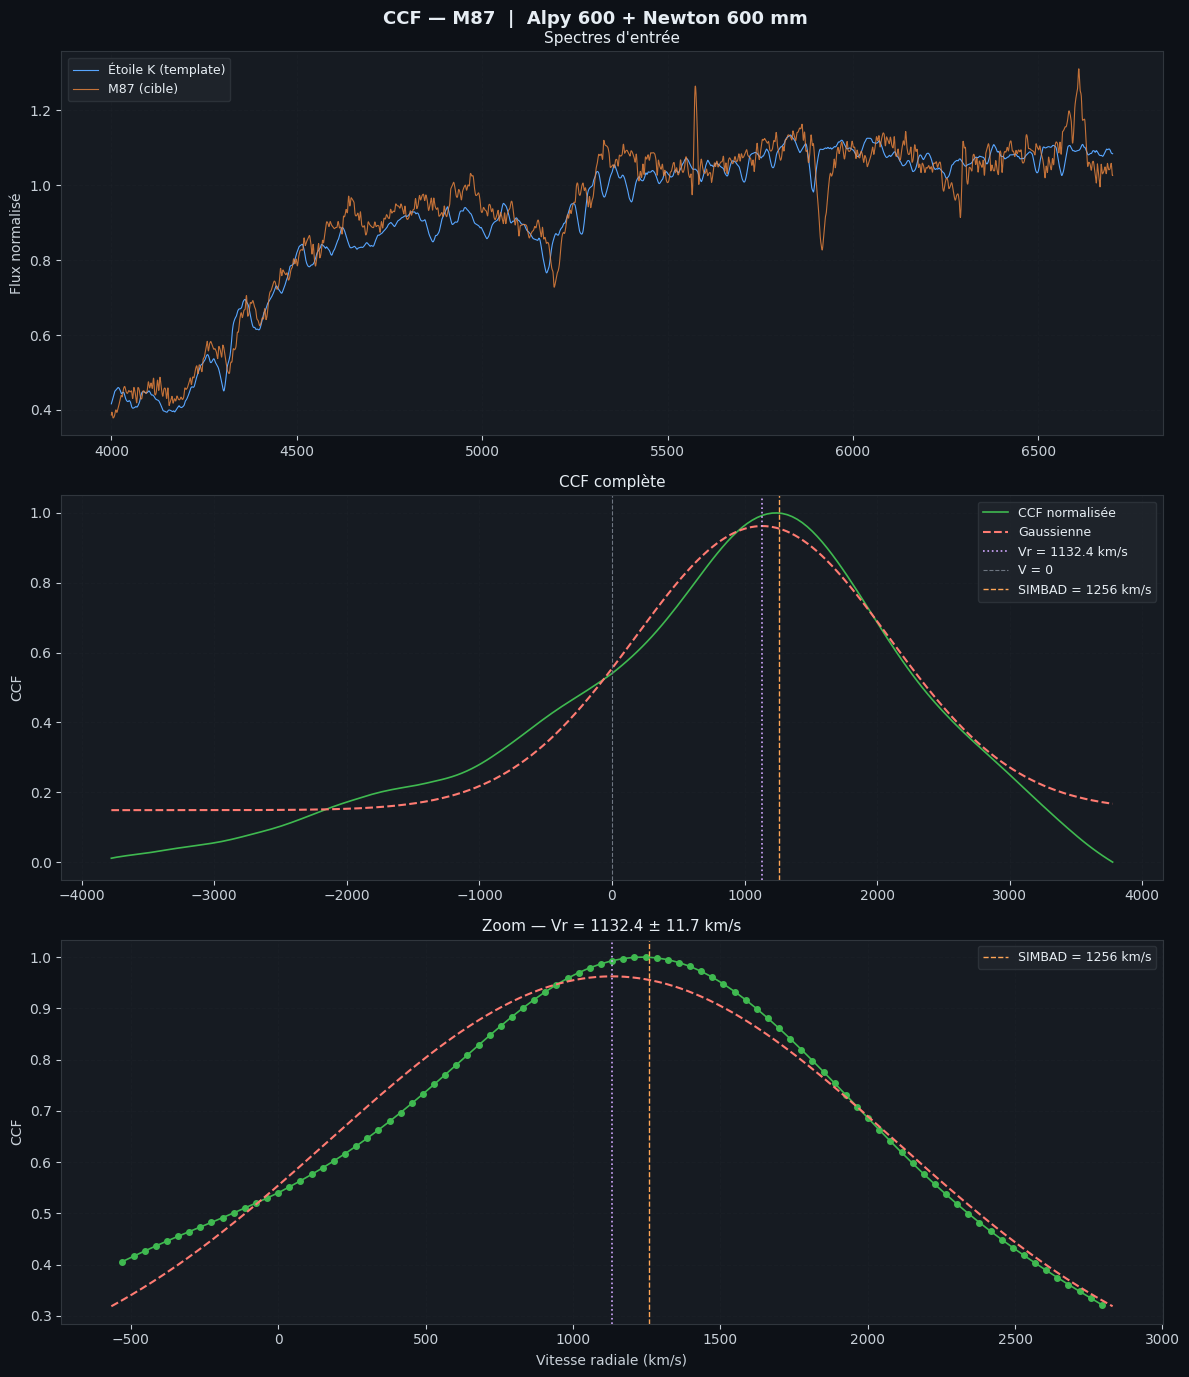

Figure sauvegardée : ccf_M87.png


In [ ]:
C_REF, C_CIB, C_CCF, C_FIT, C_RV = '#58a6ff','#f0883e','#3fb950','#ff7b72','#d2a8ff'
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Panneau 1 : spectres
ax = axes[0]
ax.plot(lam_ref, flux_ref/np.nanmedian(flux_ref),
        color=C_REF, lw=0.8, label='Étoile K (template)')
ax.plot(lam_cib, flux_cib/np.nanmedian(flux_cib),
        color=C_CIB, lw=0.8, label=f'{NOM_OBJET} (cible)', alpha=0.8)
ax.set_ylabel('Flux normalisé'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title('Spectres d\'entrée', fontsize=11)

# Panneau 2 : CCF complète
ax = axes[1]
ax.plot(vitesses, ccf, color=C_CCF, lw=1.2, label='CCF normalisée')
if popt is not None:
    vv = np.linspace(vitesses[0], vitesses[-1], 2000)
    ax.plot(vv, gaussienne(vv, *popt), color=C_FIT, lw=1.5, ls='--', label='Gaussienne')
ax.axvline(v_rv, color=C_RV, lw=1.2, ls=':', label=f'Vr = {v_rv:.1f} km/s')
ax.axvline(0, color='#6e7681', lw=0.8, ls='--', label='V = 0')
if vr_simbad:
    ax.axvline(vr_simbad, color='#ffa657', lw=1.0, ls='--',
               label=f'SIMBAD = {vr_simbad:.0f} km/s')
ax.set_ylabel('CCF'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title('CCF complète', fontsize=11)

# Panneau 3 : zoom pic
ax = axes[2]
zoom = max(abs(v_rv)*1.5, 1500)
mz = np.abs(vitesses - v_rv) < zoom
ax.plot(vitesses[mz], ccf[mz], color=C_CCF, lw=1.2, marker='o', ms=4)
if popt is not None:
    vz = np.linspace(v_rv - zoom, v_rv + zoom, 1000)
    ax.plot(vz, gaussienne(vz, *popt), color=C_FIT, lw=1.5, ls='--')
ax.axvline(v_rv, color=C_RV, lw=1.2, ls=':')
if vr_simbad:
    ax.axvline(vr_simbad, color='#ffa657', lw=1.0, ls='--',
               label=f'SIMBAD = {vr_simbad:.0f} km/s')
    ax.legend(fontsize=9)
sig_str = f' ± {incertitude:.1f}' if not (incertitude != incertitude) else ''
ax.set_title(f'Zoom — Vr = {v_rv:.1f}{sig_str} km/s', fontsize=11)
ax.set_xlabel('Vitesse radiale (km/s)'); ax.set_ylabel('CCF'); ax.grid(alpha=0.3)

fig.suptitle(f'CCF — {NOM_OBJET}  |  Alpy 600 + Newton 600 mm',
             fontsize=13, fontweight='bold')
plt.tight_layout()

nom_sortie = f'ccf_{NOM_OBJET.replace(" ","_")}.png'
plt.savefig(nom_sortie, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Figure sauvegardée : {nom_sortie}')

## 8. Correction héliocentrique

In [ ]:
# Date d'observation depuis l'en-tête du FITS cible
with fits.open(FICHIER_CIBLE) as hdul:
    hdr = hdul[0].header
    date_obs = (
        hdr.get('DATE-OBS') or
        hdr.get('DATE_OBS') or
        hdr.get('DATE')
    )
    ra_fits  = hdr.get('RA')
    dec_fits = hdr.get('DEC')

if date_obs is None:
    raise ValueError("Aucun mot-clé de date trouvé dans l'en-tête FITS.")

t = Time(date_obs, scale='utc')
print(f'DATE-OBS : {date_obs}  →  JD = {t.jd:.5f}')

# Coordonnées : SIMBAD déjà interrogé en cellule 5
corr     = sc.radial_velocity_correction('heliocentric', obstime=t, location=obs)
corr_kms = corr.to(u.km/u.s).value
v_helio  = v_rv + corr_kms

print(f'\n{"═"*48}')
print(f'  Objet                : {NOM_OBJET}')
print(f'  Vr géocentrique      : {v_rv:+.1f} km/s')
print(f'  Correction hélio     : {corr_kms:+.1f} km/s')
print(f'  Vr héliocentrique    : {v_helio:+.1f} km/s')
if vr_simbad:
    print(f'  Vr SIMBAD (réf.)     : {vr_simbad:+.1f} km/s')
    print(f'  Résidu               : {v_helio - vr_simbad:+.1f} km/s')
print(f'{"═"*48}')

DATE-OBS : 2016-12-02T21:11:59  →  JD = 2457725.38332

════════════════════════════════════════════════
  Objet                : NGC821
  Vr géocentrique      : +1457.6 km/s
  Correction hélio     : -18.5 km/s
  Vr héliocentrique    : +1439.1 km/s
  Vr SIMBAD (réf.)     : +1737.9 km/s
  Résidu               : -298.8 km/s
════════════════════════════════════════════════


## 9. Notes pratiques

### Vitesses SIMBAD des cibles du programme
| Objet | Vr SIMBAD (km/s) | Demi-intervalle auto (km/s) |
|---|---|---|
| M74 (NGC 628) | +657 | 1 971 |
| M87 (NGC 4486) | +1 284 | 3 852 |
| NGC 821 | +1 718 | 5 154 |
| NGC 1954 | +3 994 | 11 982 |
| NGC 1700 | +3 899 | 11 697 |
| NGC 777 | +4 956 | 14 868 |

> Pour NGC 1954, NGC 1700 et NGC 777, la vitesse est élevée (~4 000–5 000 km/s).  
> Le décalage en longueur d'onde est alors perceptible à l'œil dans le panneau spectres (raies décalées vers le rouge).

### Si le pic est mal formé
- **Pic large ou asymétrique** → SNR insuffisant, augmenter le temps de pose
- **Pic absent** → vérifier que les deux FITS couvrent la même plage spectrale
- **Pic au mauvais endroit** → vérifier l'en-tête WCS (`CRVAL1`, `CDELT1`) dans les deux fichiers
- **Résidu > 100 km/s** → vérifier la vitesse propre de l'étoile K template (SIMBAD)